<a href="https://colab.research.google.com/github/SMayurgavali/PROJECT/blob/main/machine_learning_classification_project_credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder

In [ ]:
data = pd.read_csv("/content/creditcard.csv")

In [ ]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
data.shape

(103088, 31)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103088 entries, 0 to 103087
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    103088 non-null  int64  
 1   V1      103088 non-null  float64
 2   V2      103088 non-null  float64
 3   V3      103088 non-null  float64
 4   V4      103088 non-null  float64
 5   V5      103088 non-null  float64
 6   V6      103088 non-null  float64
 7   V7      103088 non-null  float64
 8   V8      103088 non-null  float64
 9   V9      103088 non-null  float64
 10  V10     103088 non-null  float64
 11  V11     103088 non-null  float64
 12  V12     103088 non-null  float64
 13  V13     103088 non-null  float64
 14  V14     103088 non-null  float64
 15  V15     103088 non-null  float64
 16  V16     103088 non-null  float64
 17  V17     103088 non-null  float64
 18  V18     103088 non-null  float64
 19  V19     103088 non-null  float64
 20  V20     103088 non-null  float64
 21  V21     10

In [ ]:
data.describe().T   # T is used for transfer rows to column and column to rows

,count,mean,std,min,25%,50%,75%,max
Time,103088.0,43195.783496,17339.553909,0.000000,33760.000000,45003.000000,56992.500000,68489.000000
V1,103088.0,-0.259278,1.851810,-56.407510,-1.026222,-0.262181,1.154372,1.960497
V2,103088.0,-0.032491,1.650426,-72.715728,-0.600738,0.075028,0.733932,18.902453
V3,103088.0,0.684622,1.321775,-33.680984,0.179380,0.759434,1.386306,4.226108
V4,103088.0,0.156327,1.346277,-5.172595,-0.715776,0.184192,1.027020,16.715537
V5,103088.0,-0.283952,1.355148,-42.147898,-0.908043,-0.318363,0.245974,34.801666
V6,103088.0,0.099404,1.302138,-26.160506,-0.643339,-0.151559,0.494781,22.529298
V7,103088.0,-0.116461,1.217442,-31.764946,-0.606811,-0.072630,0.410230,36.677268
V8,103088.0,0.056888,1.237722,-73.216718,-0.135589,0.076816,0.367677,20.007208
V9,103088.0,-0.046868,1.115283,-9.283925,-0.694322,-0.115372,0.556107,10.392889


In [ ]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64

In [ ]:
data.dropna(inplace = True)

In [ ]:
data.shape

(103087, 31)

In [ ]:
data.duplicated().sum()

386

In [ ]:
data[data.duplicated()]['Class'].value_counts()   # check number of duplicated entries.

Class
0.0    381
1.0      5
Name: count, dtype: int64

In [ ]:
data['Class'].value_counts()  # here 232 entries are fraud...

Class
0.0    102855
1.0       232
Name: count, dtype: int64

<Axes: >

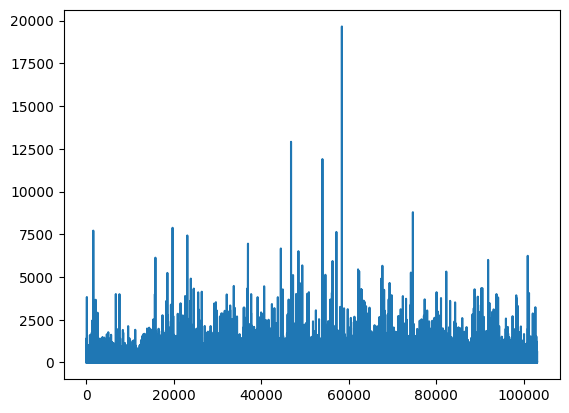

In [ ]:
data['Amount'].plot()

<Axes: >

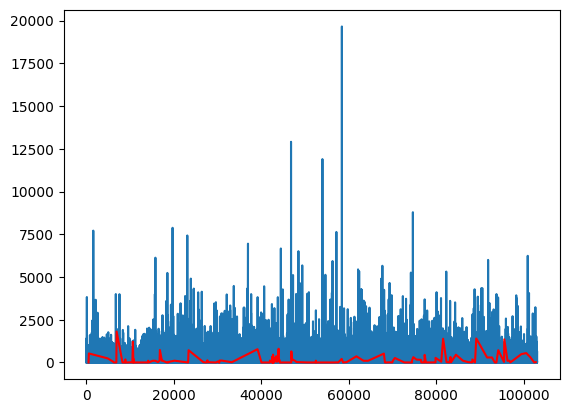

In [ ]:
data[data['Class']==0.0]['Amount'].plot()
data[data['Class']==1.0]['Amount'].plot(c = 'r')

<Axes: xlabel='Amount'>

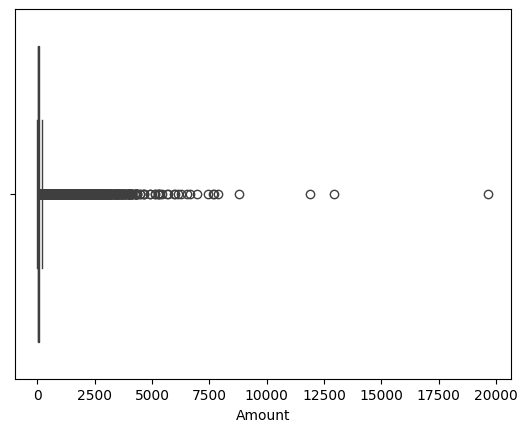

In [ ]:
sns.boxplot(data = data, x = 'Amount')

([<matplotlib.patches.Wedge at 0x7be5b9b680a0>,
 [Text(-1.0999725059449377, 0.007777285208498055, '0.0'),
  Text(1.099972505313481, -0.007777374517414345, '1.0')])

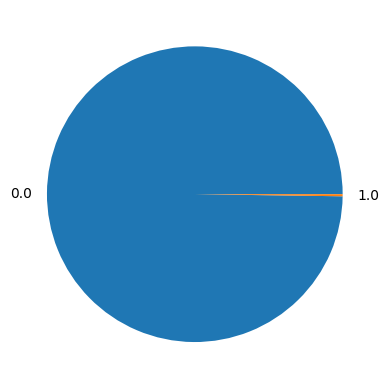

In [ ]:
vc = data['Class'].value_counts()
plt.pie(vc.values, labels = vc.index)

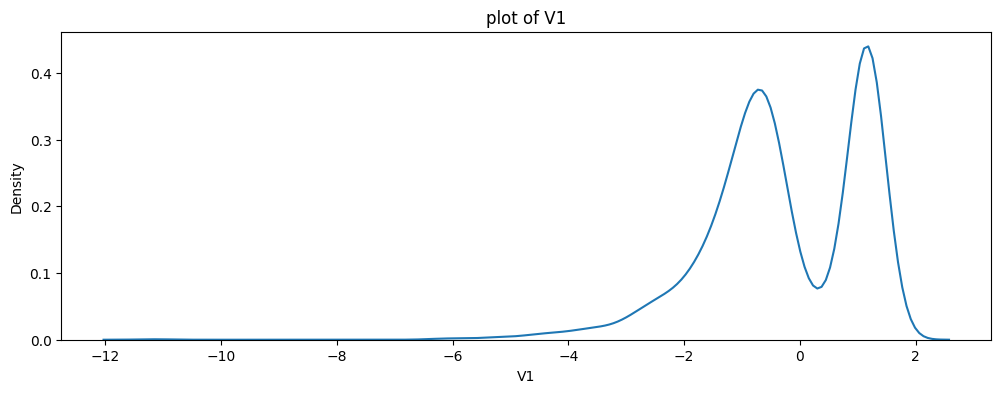

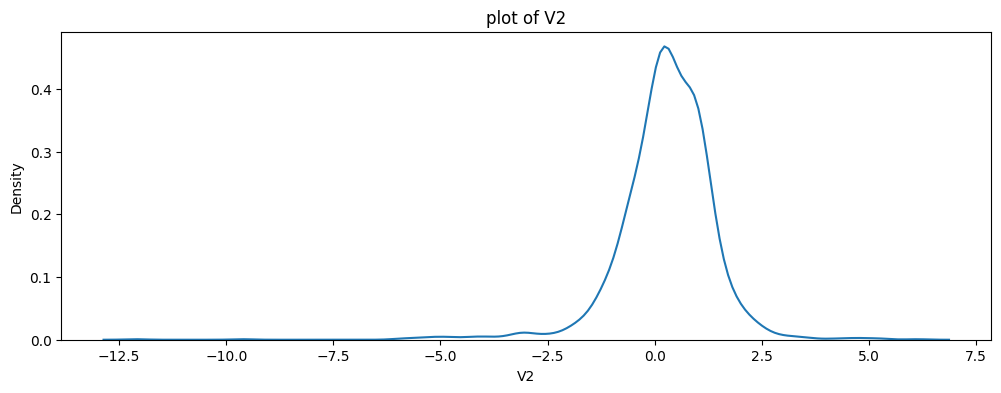

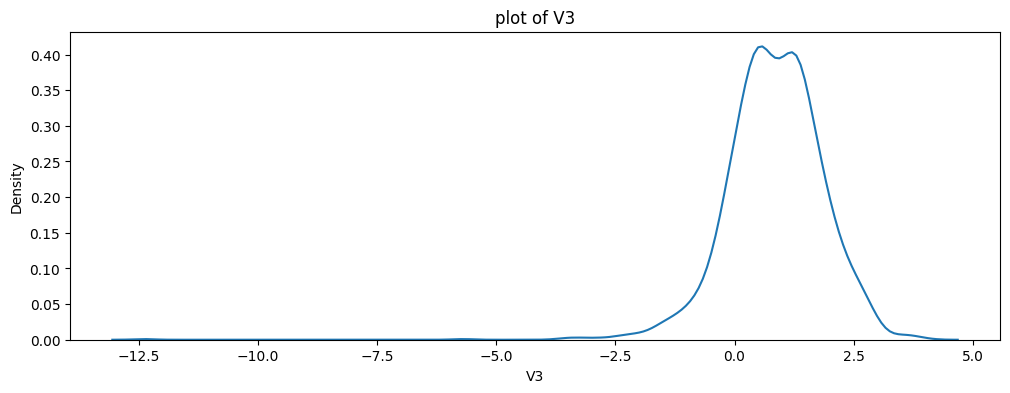

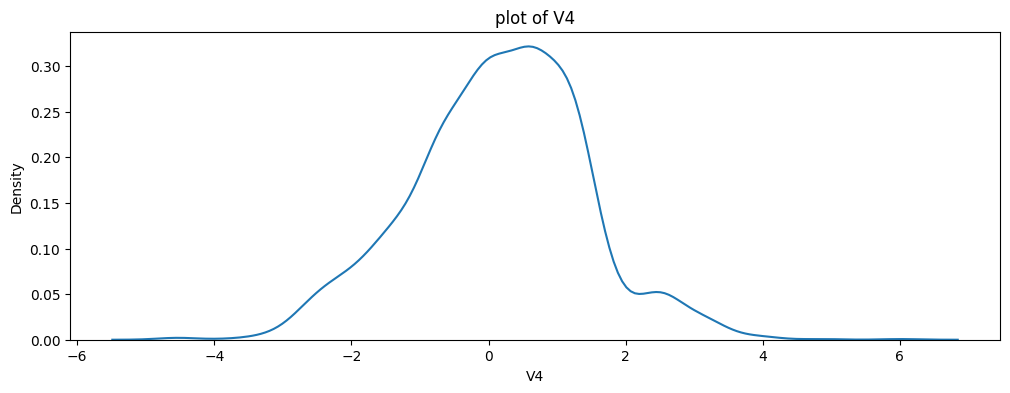

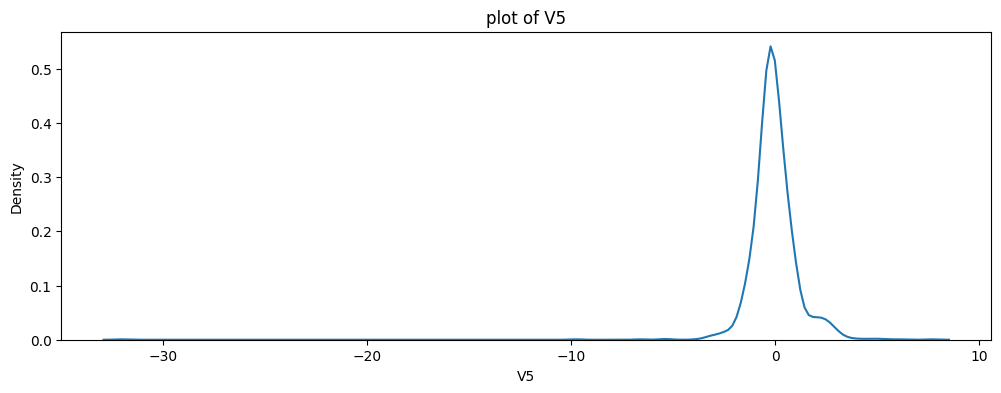

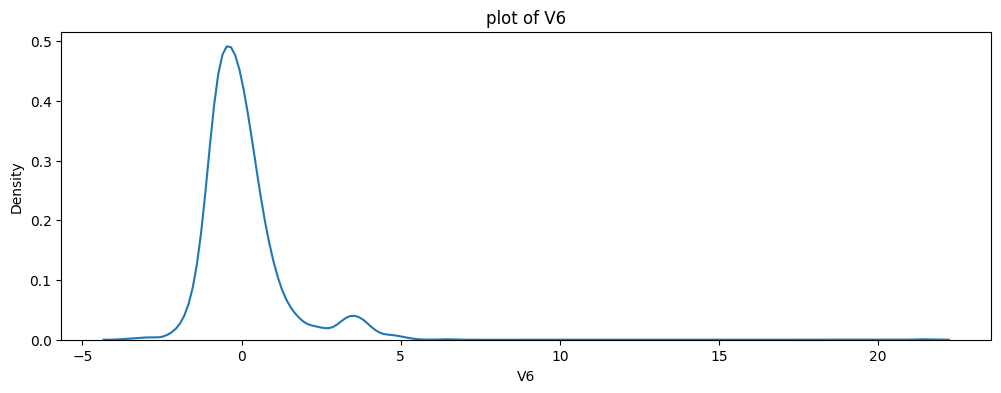

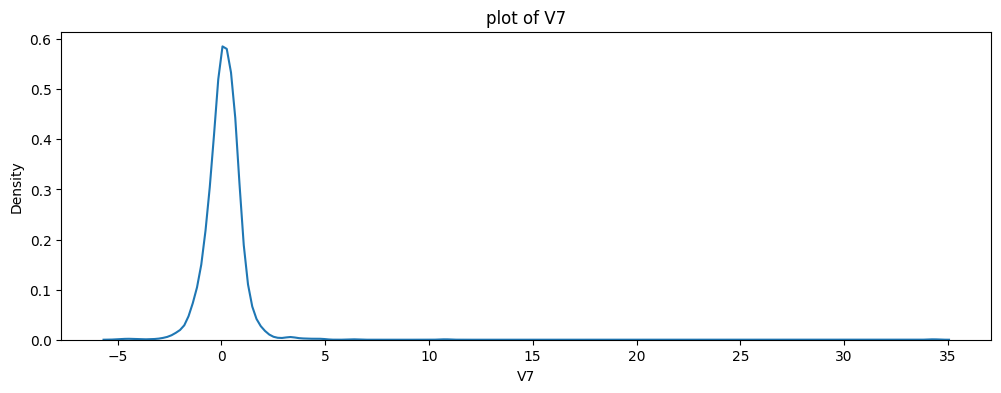

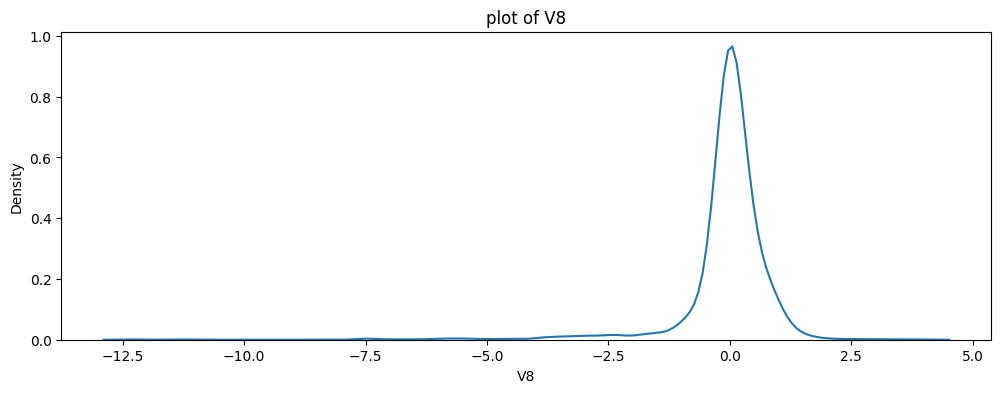

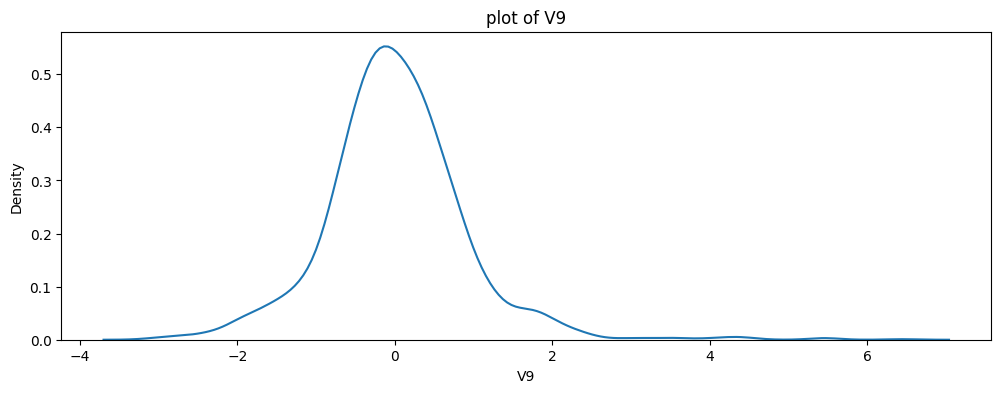

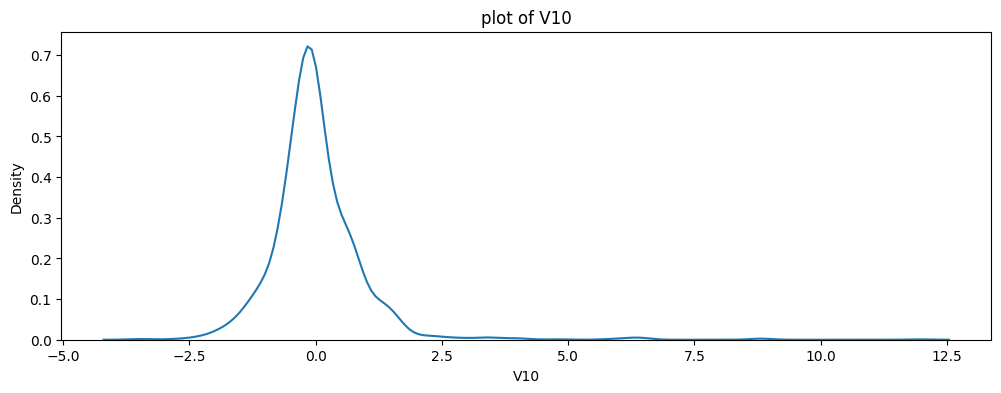

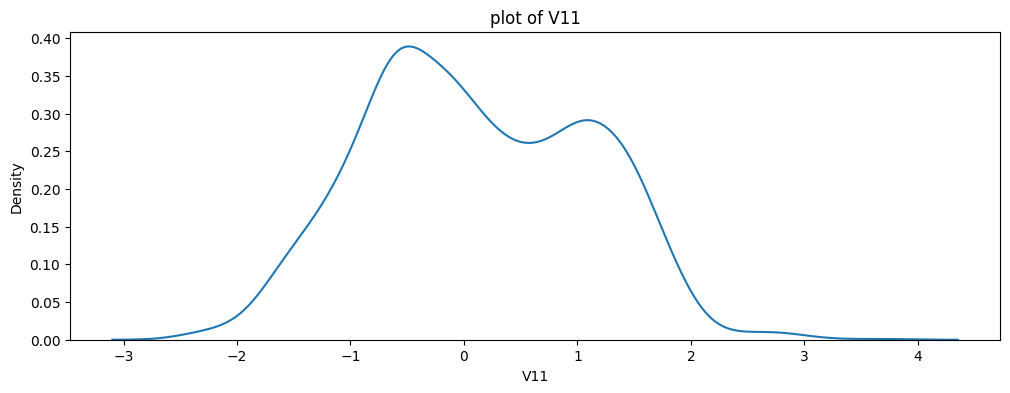

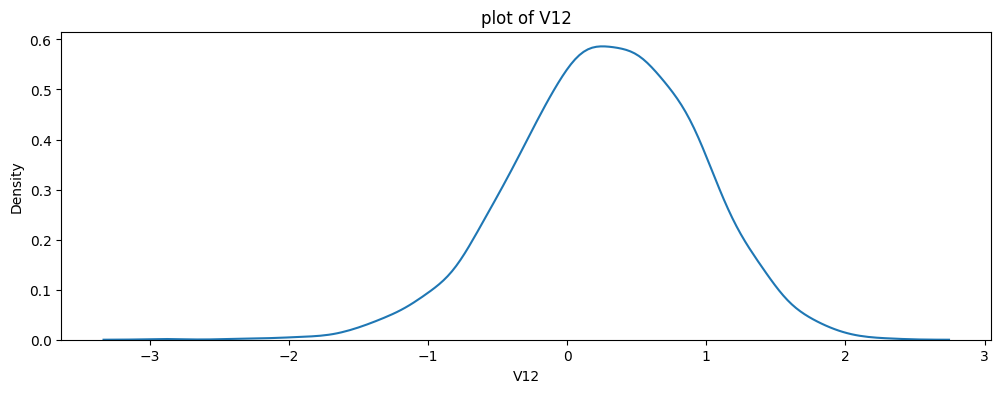

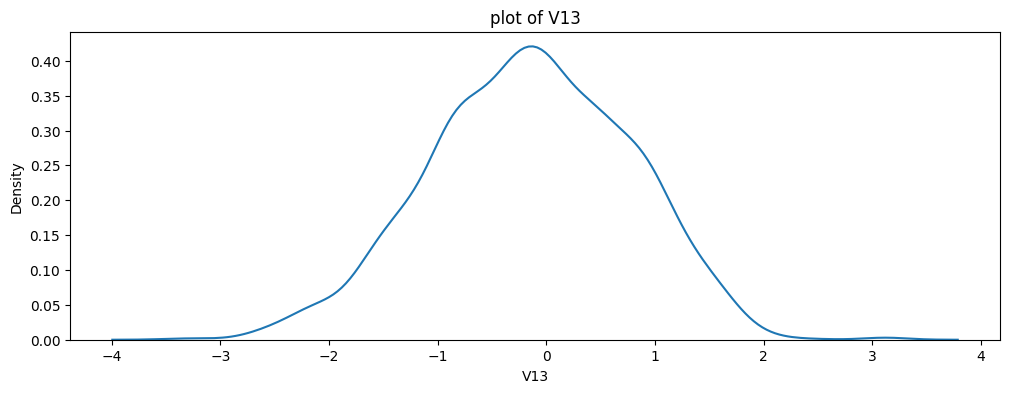

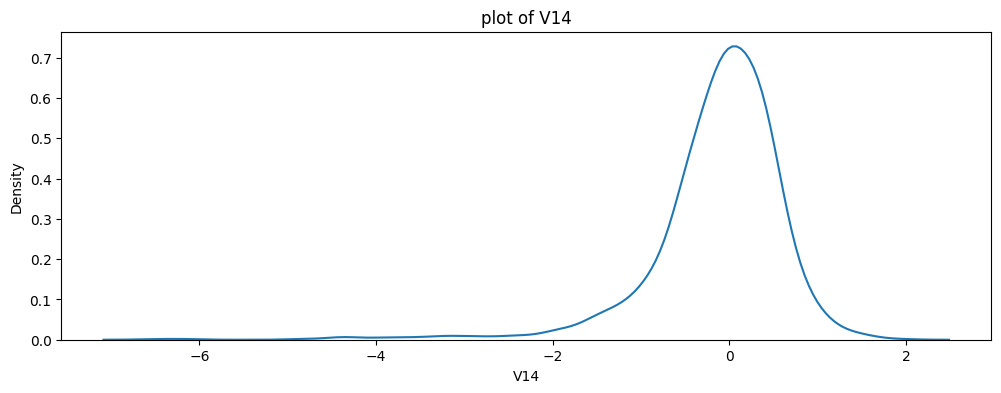

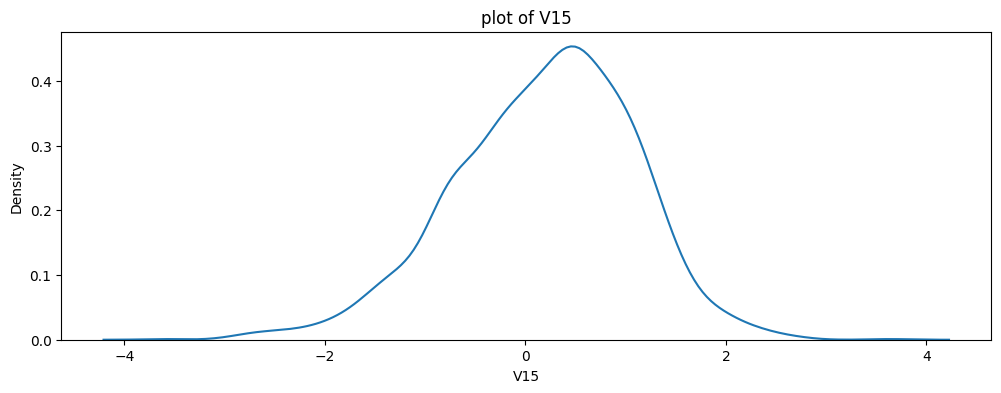

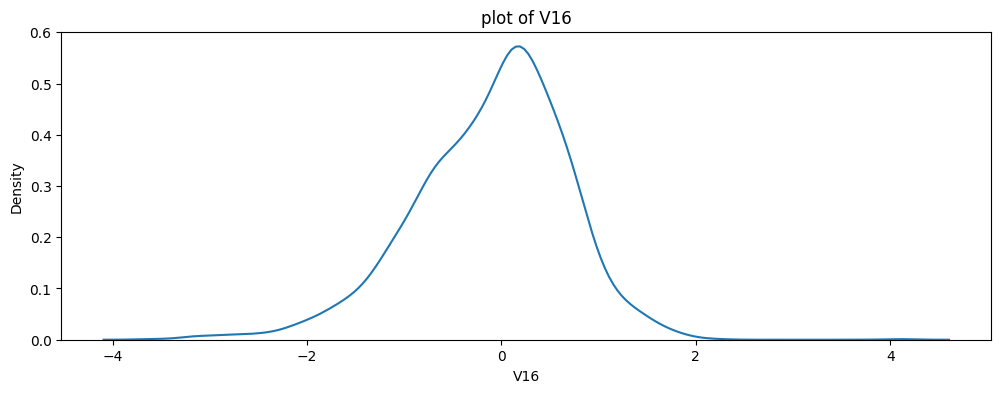

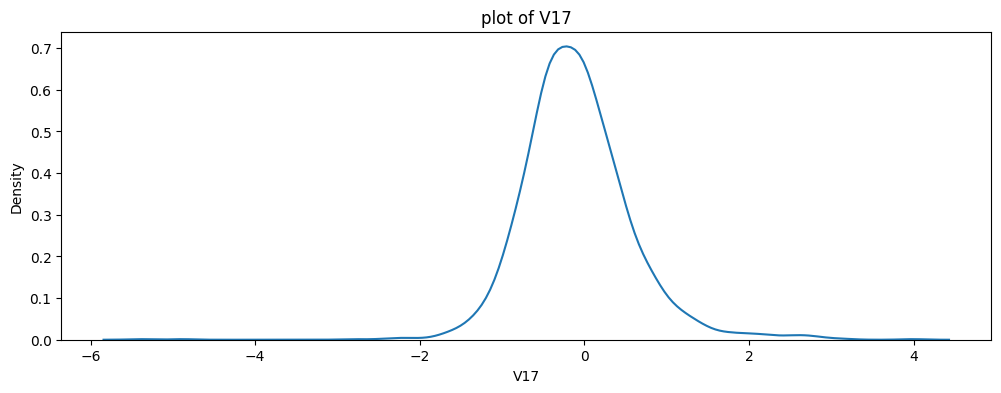

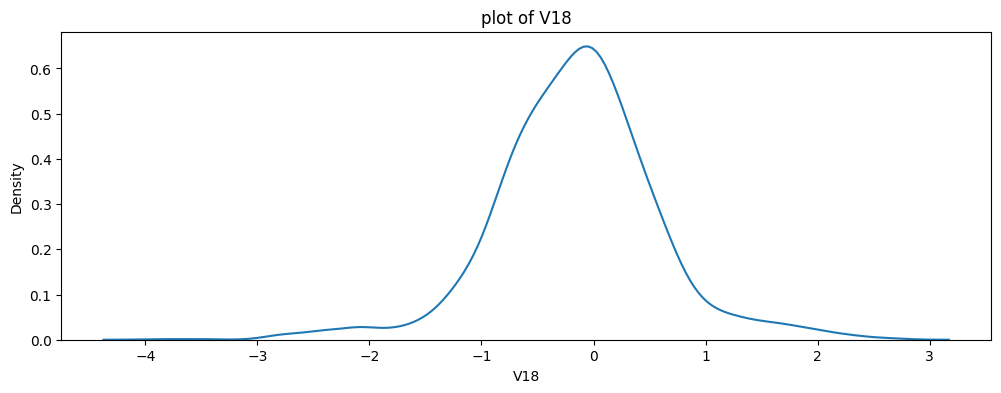

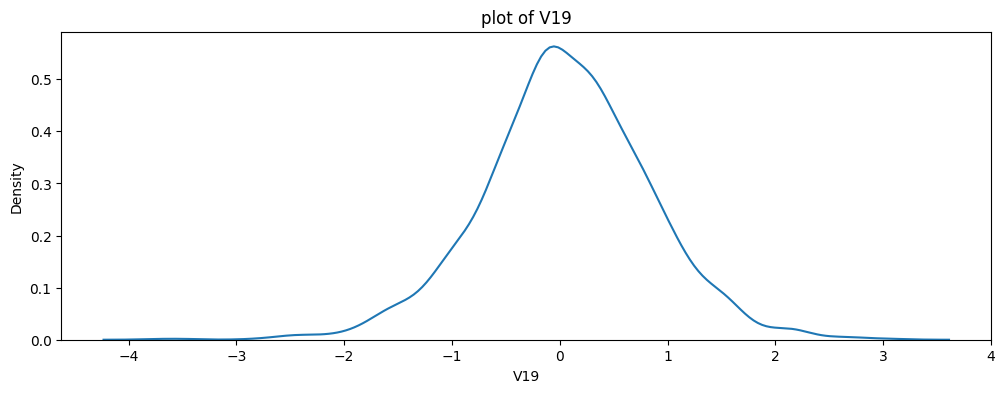

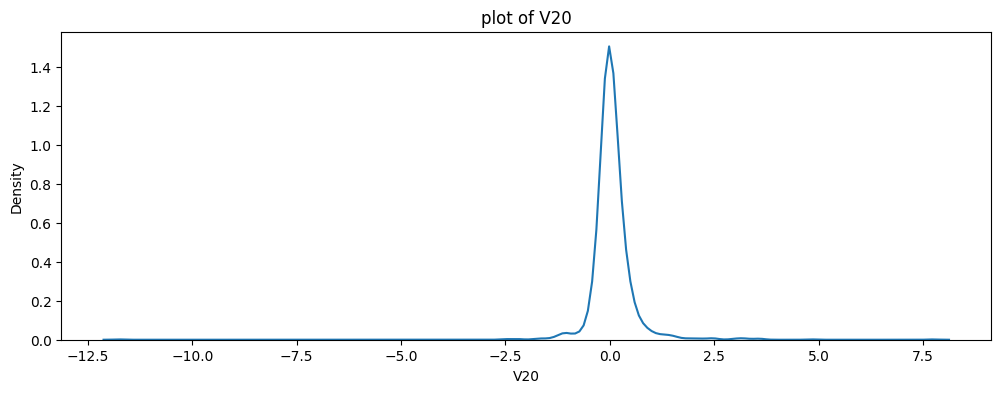

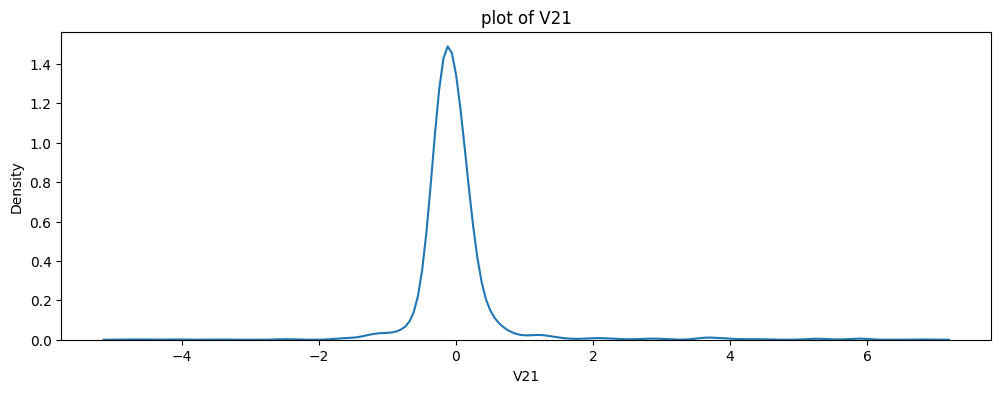

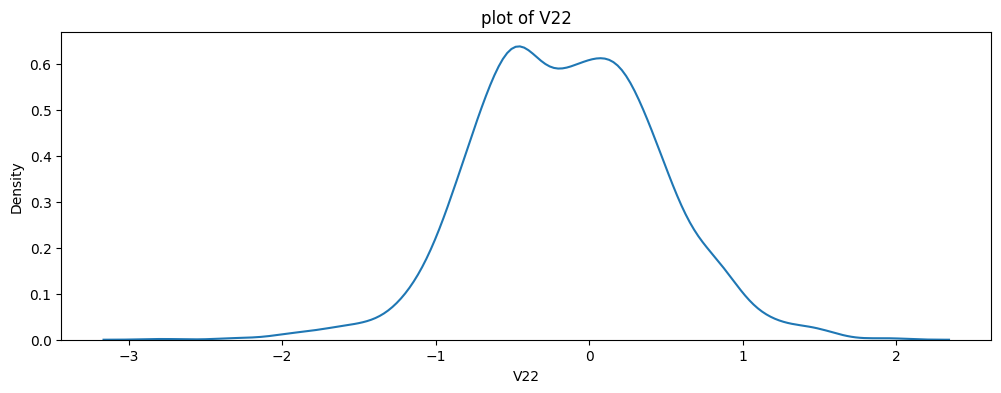

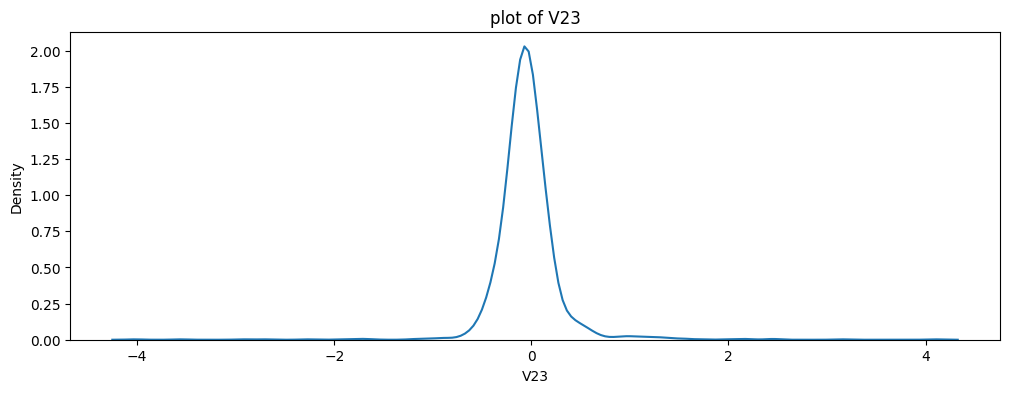

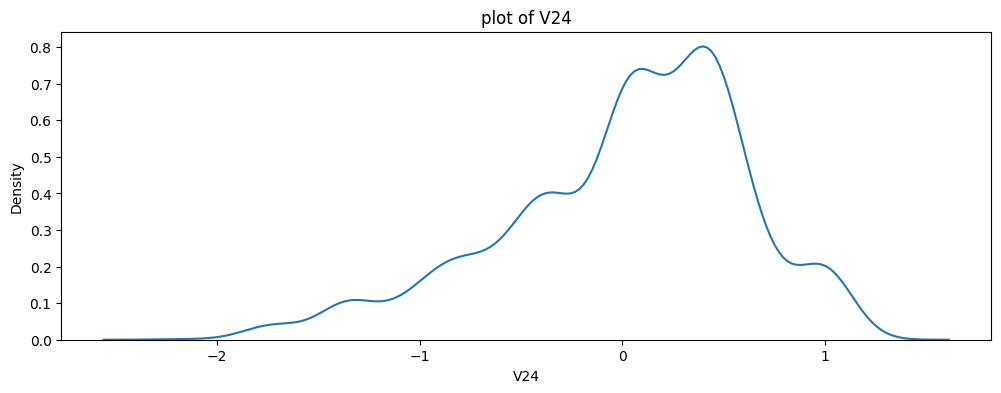

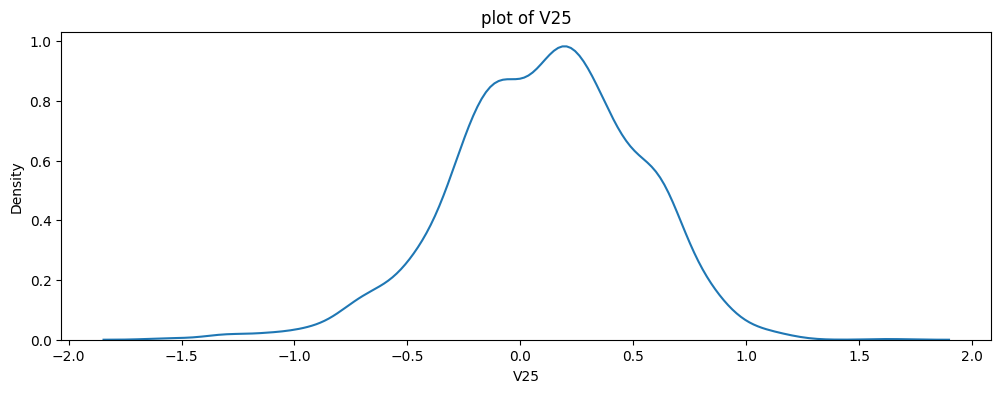

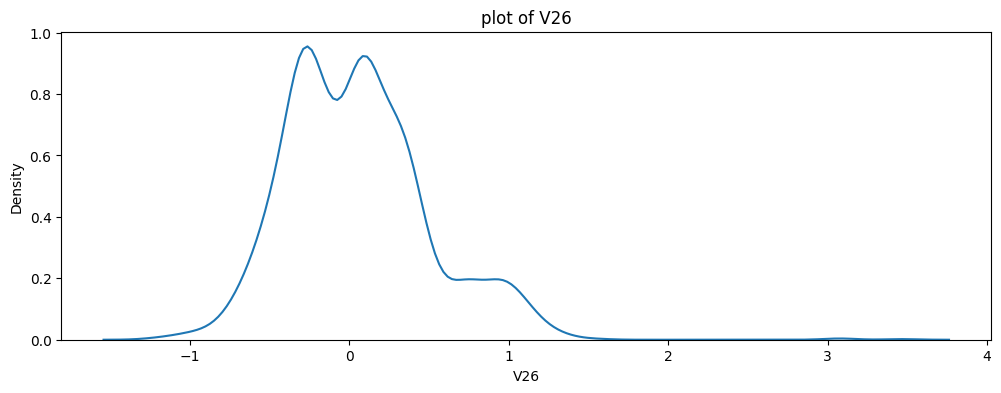

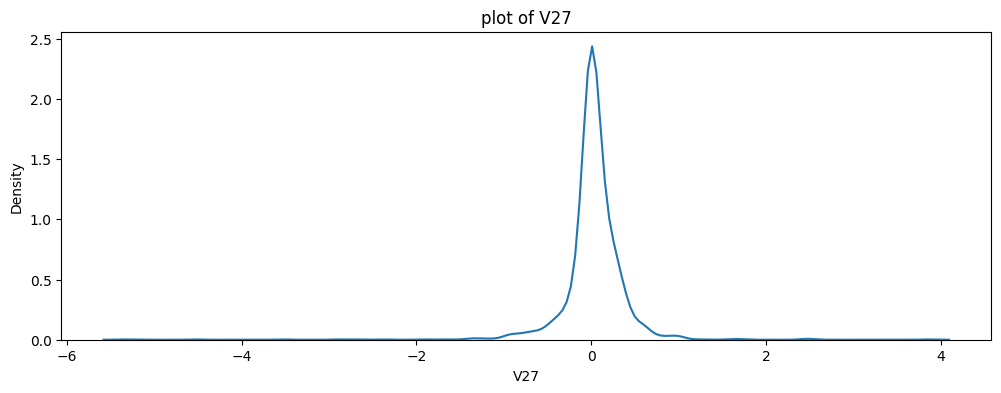

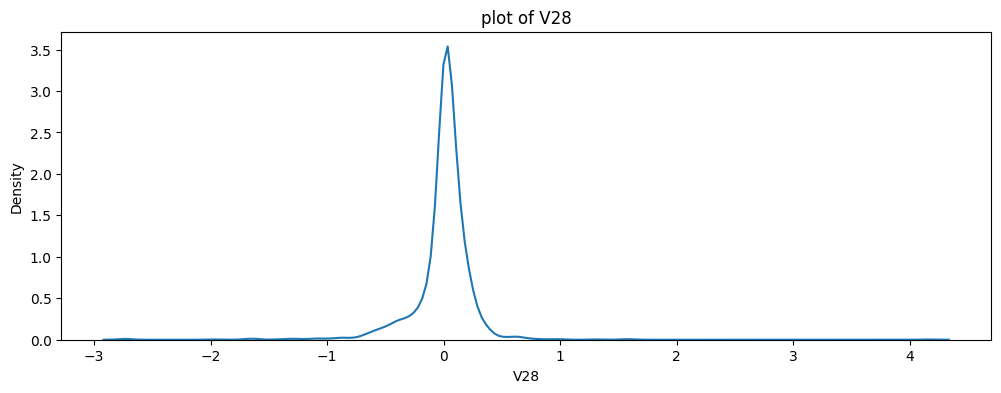

In [ ]:
for c in data.columns[1 : -2]:
  plt.figure(figsize = (12,4))
  plt.title(f"plot of {c}")
  sns.kdeplot(data = data, x = c)
  plt.show()

In [ ]:
data['Amount'].describe()

count    1985.000000
mean       68.602469
std       241.677019
min         0.000000
25%         4.950000
50%        15.090000
75%        63.650000
max      7712.430000
Name: Amount, dtype: float64

In [ ]:
(data['Amount']==0.0).sum()

13

In [ ]:
data[data['Amount']==0]['Class'].value_counts()

Class
0.0    12
1.0     1
Name: count, dtype: int64

In [ ]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
from sklearn.preprocessing import RobustScaler


In [ ]:
x = data.drop(['Class'], axis = 1)
y = data['Class']

<Axes: >

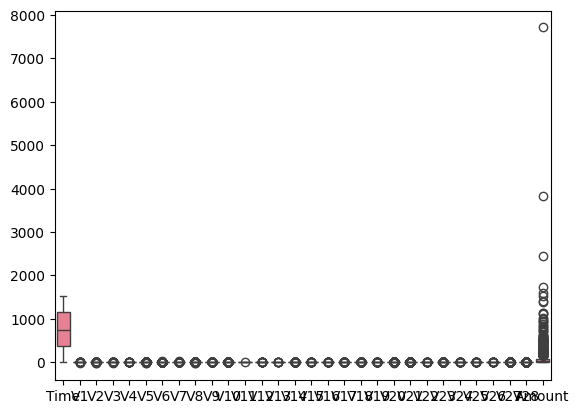

In [ ]:
sns.boxplot(x)